In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import Basic_functions as bf
from scipy.sparse import vstack, hstack, csr_matrix, save_npz, load_npz


import torch as pt
import optuna as opt
import sklearn.metrics as skm
import sklearn.utils as sku
from sklearn.preprocessing import StandardScaler

In [71]:
import torch.nn as nn
from torch.nn import CrossEntropyLoss
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)
import optuna as opt
#from torch.nn import L1Loss
#from scipy.special import expit

In [85]:
data_00 = load_npz("Data_files/data_articles_00.npz")
data_01 = load_npz("Data_files/data_articles_01.npz")
data_02 = load_npz("Data_files/data_articles_02.npz")
data_03 = load_npz("Data_files/data_articles_03.npz")
data_08 = load_npz("Data_files/data_articles_08.npz")
data_09 = load_npz("Data_files/data_articles_09.npz")
data_10 = load_npz("Data_files/data_articles_10.npz")
data_11 = load_npz("Data_files/data_articles_11.npz")
data_12 = load_npz("Data_files/data_articles_12.npz")
data_13 = load_npz("Data_files/data_articles_13.npz")
data_14 = load_npz("Data_files/data_articles_14.npz")
data_15 = load_npz("Data_files/data_articles_15.npz")
data_17 = load_npz("Data_files/data_articles_17.npz")
data_18 = load_npz("Data_files/data_articles_18.npz")

data_articles = vstack([data_00, data_01, data_02, data_03, data_08, data_09, data_10, data_11, data_12, data_13, data_14, data_15, data_17, data_18])
labels_article_00 = np.genfromtxt("Data_files/labels_articles_00.txt", delimiter="; ", dtype=str)
labels_article_01 = np.genfromtxt("Data_files/labels_articles_01.txt", delimiter="; ", dtype=str)
labels_article_02 = np.genfromtxt("Data_files/labels_articles_02.txt", delimiter="; ", dtype=str)
labels_article_03 = np.genfromtxt("Data_files/labels_articles_03.txt", delimiter="; ", dtype=str)
labels_article_08 = np.genfromtxt("Data_files/labels_articles_08.txt", delimiter="; ", dtype=str)
labels_article_09 = np.genfromtxt("Data_files/labels_articles_09.txt", delimiter="; ", dtype=str)
labels_article_10 = np.genfromtxt("Data_files/labels_articles_10.txt", delimiter="; ", dtype=str)
labels_article_11 = np.genfromtxt("Data_files/labels_articles_11.txt", delimiter="; ", dtype=str)
labels_article_12 = np.genfromtxt("Data_files/labels_articles_12.txt", delimiter="; ", dtype=str)
labels_article_13 = np.genfromtxt("Data_files/labels_articles_13.txt", delimiter="; ", dtype=str)
labels_article_14 = np.genfromtxt("Data_files/labels_articles_14.txt", delimiter="; ", dtype=str)
labels_article_15 = np.genfromtxt("Data_files/labels_articles_15.txt", delimiter="; ", dtype=str)
labels_article_17 = np.genfromtxt("Data_files/labels_articles_17.txt", delimiter="; ", dtype=str)
labels_article_18 = np.genfromtxt("Data_files/labels_articles_18.txt", delimiter="; ", dtype=str)
labels_articles = np.concatenate([labels_article_00, labels_article_01, labels_article_02, labels_article_03, labels_article_08, labels_article_09, labels_article_10, labels_article_11, labels_article_12, labels_article_13, labels_article_14, labels_article_15, labels_article_17, labels_article_18])
data_articles, labels_articles = sku.shuffle(data_articles, labels_articles, random_state=42)

In [183]:
data_speeches = load_npz('Data_files/data_speech.npz')
data_speeches_nltk = load_npz("tfidf_NLTK_Speeches.npz")
labels_speeches = np.genfromtxt('Data_files/labels_speech.txt', delimiter='; ', dtype=str)
speech_sort = np.genfromtxt('txt_files/sermons_sort_idx.txt', delimiter='\n', dtype=int)

data_comb = vstack([data_articles[:len(labels_speeches)*10], data_speeches])
labels_comb = np.concatenate([labels_articles[:len(labels_speeches)*10], labels_speeches])
class_labels_comb = np.concatenate([np.zeros(len(labels_speeches)*10),np.ones(len(labels_speeches))])
data_comb = data_speeches[:, speech_sort][:, :250]

data_comb = hstack([labels_speeches[:,4].astype(float).reshape(-1, 1), data_speeches_nltk], format="csr")

In [184]:
data_comb, class_labels_comb = sku.shuffle(data_comb, labels_speeches[:,1].astype(int), random_state=5466542)
scaler = StandardScaler(with_mean=False)
data_comb_scaled = scaler.fit_transform(data_comb)

In [185]:
data_train, data_train_labels, data_val, data_val_labels, data_test, data_test_labels = bf.train_val_test_split(data_comb_scaled, class_labels_comb, val_size=0.20, test_size=0.10)

In [186]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

In [136]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [137]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [189]:
def objective(trial):
# Define the model:
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    n_epochs = 10
    batch_size = trial.suggest_int('batch_size', 8, 128)
    Layer1 = trial.suggest_int('Layer1', 12, 512)
    Layer2 = trial.suggest_int('Layer2', 12, 512)
    Layer3 = trial.suggest_int('Layer3', 12, 512)

    class OptModel(nn.Module):
        def __init__(self):
            super(OptModel, self).__init__()        # Here we define the layers.
            self.input_layer = nn.Linear(7328, Layer1)     #In pytorch, you define the input and output edges.
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, 2)
            self.relu = nn.ReLU()
            
        def forward(self, inputs):                  # Here we define how data passes through the layers. 
            x = self.input_layer(inputs)            # Also here, pytorch is a bit more explicit in defining the layers and activation function separately
            x = self.relu(x)
            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.output_layer(x)
            return x
        
    device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
    model_opt = OptModel()
    sparse_config = {
    "seq.0": SemiSparseLinear,
    }
    swap_linear_with_semi_sparse_linear(model_opt, sparse_config)
    model_opt.to(device)

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_opt.parameters(), lr=learning_rate)
    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, collate_fn=sparse_collate)
    validation_loader = DataLoader(dataset=val_data, batch_size=batch_size, collate_fn=sparse_collate)

    training_loss, validation_loss = Train(model_opt, optimizer, loss_function, train_loader, validation_loader, device, n_epochs)

    return min(validation_loss)

In [190]:
opt.logging.set_verbosity(opt.logging.WARNING)
study = opt.create_study(direction='minimize')
study.optimize(objective, n_trials=30)
print("Best trial:", study.best_trial)

EPOCH: 1 | training loss: 0.134  | validation loss: 0.066
EPOCH: 2 | training loss: 0.009  | validation loss: 0.101
EPOCH: 3 | training loss: 0.001  | validation loss: 0.14
EPOCH: 4 | training loss: 0.0  | validation loss: 0.147
EPOCH: 5 | training loss: 0.0  | validation loss: 0.148
EPOCH: 6 | training loss: 0.0  | validation loss: 0.148
EPOCH: 7 | training loss: 0.0  | validation loss: 0.15
EPOCH: 8 | training loss: 0.0  | validation loss: 0.154
EPOCH: 9 | training loss: 0.0  | validation loss: 0.16
EPOCH: 10 | training loss: 0.0  | validation loss: 0.165
EPOCH: 1 | training loss: 0.688  | validation loss: 0.672
EPOCH: 2 | training loss: 0.658  | validation loss: 0.639
EPOCH: 3 | training loss: 0.62  | validation loss: 0.593
EPOCH: 4 | training loss: 0.567  | validation loss: 0.535
EPOCH: 5 | training loss: 0.509  | validation loss: 0.477
EPOCH: 6 | training loss: 0.453  | validation loss: 0.426
EPOCH: 7 | training loss: 0.405  | validation loss: 0.385
EPOCH: 8 | training loss: 0.363

In [ ]:
learning_rate = 1e-04   
batch_size    = 32    
n_epochs      = 5    
class SermonModel(nn.Module):
    def __init__(self):
        super(SermonModel, self).__init__()       
        self.input_layer = nn.Linear(7328, 256)     
        self.hidden_layer1 = nn.Linear(256, 128)
        self.hidden_layer2 = nn.Linear(128, 8)
        self.output_layer = nn.Linear(8, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x
    
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
model = SermonModel() 
sparse_config = {
    "seq.0": SemiSparseLinear,
}
swap_linear_with_semi_sparse_linear(model, sparse_config)
model.to(device)       # Mount the model to the selected device. Either CPU or GPU.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_function = CrossEntropyLoss()Æ
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, collate_fn=sparse_collate)
validation_loader = DataLoader(dataset=val_data, batch_size=batch_size, collate_fn=sparse_collate)

training_loss, validation_loss = Train(model, optimizer, loss_function, train_loader, validation_loader, device, n_epochs)

EPOCH: 1 | training loss: 0.327  | validation loss: 0.108
EPOCH: 2 | training loss: 0.039  | validation loss: 0.049
EPOCH: 3 | training loss: 0.007  | validation loss: 0.043
EPOCH: 4 | training loss: 0.003  | validation loss: 0.044
EPOCH: 5 | training loss: 0.002  | validation loss: 0.045


In [206]:
prediction_loader = DataLoader(dataset=MyDataset(data_test, data_test_labels), batch_size=batch_size, collate_fn=sparse_collate)
predictions = Predict(model, prediction_loader, device)
predictions = pt.softmax(pt.tensor(np.array(predictions)), dim=1).numpy()[:, 1]
log_loss_score = skm.log_loss(data_test_labels, predictions)
log_loss_score

PREDICTING!
Done Predicting!


0.05182219055786213

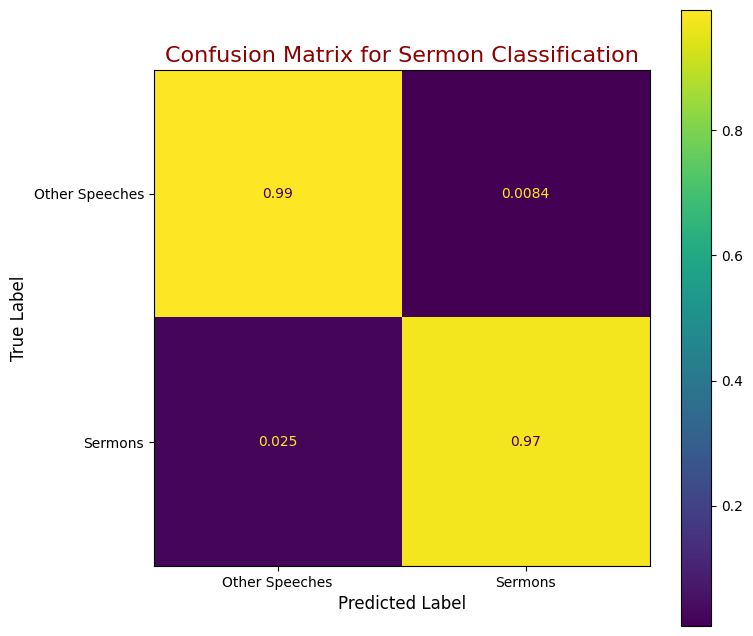

In [203]:
cm = skm.confusion_matrix(data_test_labels, predictions > 0.5, normalize='true')
classes = ["Other Speeches", "Sermons"]
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax = ax, xticks_rotation=0)
plt.title("Confusion Matrix for Sermon Classification", fontsize=16, color="darkred")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.savefig("confusion_matrix_sermons.png", dpi=300)
plt.show()

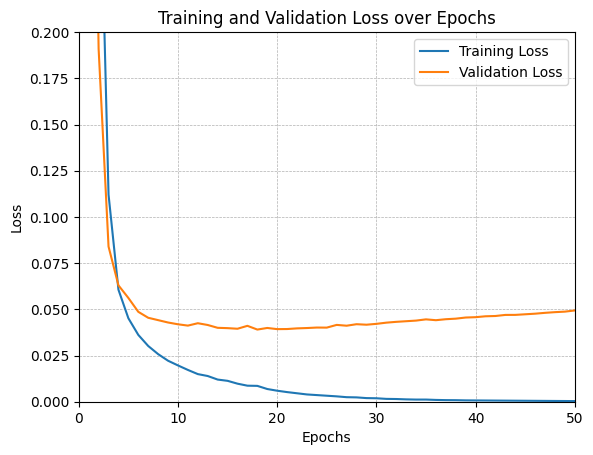

In [153]:
epochs = np.arange(1, n_epochs+1)
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.ylim(0, 0.2)
plt.xlim(0, 50)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

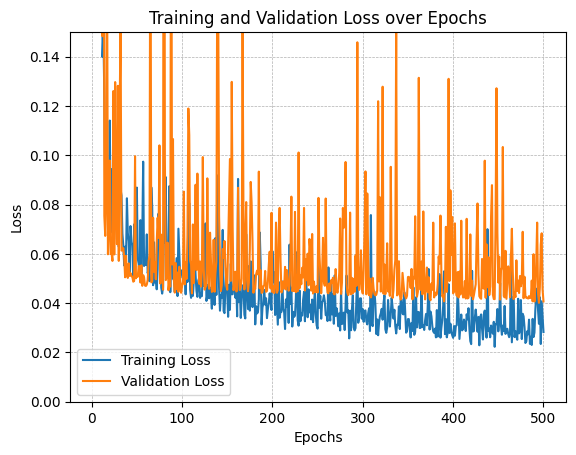

In [59]:
epochs = np.arange(1, n_epochs+1)
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.ylim(0., 0.15)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
learning_rate = 7e-05   
batch_size    = 64    
n_epochs      = 20    
class SermonModelNLTK(nn.Module):
    def __init__(self):
        super(SermonModelNLTK, self).__init__()       
        self.input_layer = nn.Linear(7328, 256)     
        self.hidden_layer1 = nn.Linear(256, 128)
        self.hidden_layer2 = nn.Linear(128, 8)
        self.output_layer = nn.Linear(8, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
learning_rate = 0.00044983189913331916   
batch_size    = 16    
n_epochs      = 4     
class SpeechModel(nn.Module):
    def __init__(self):
        super(SpeechModel, self).__init__()       
        self.input_layer = nn.Linear(251, 392)     
        self.hidden_layer1 = nn.Linear(392, 156)
        self.hidden_layer2 = nn.Linear(156, 128)
        self.output_layer = nn.Linear(128, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [ ]:
learning_rate = 7.047061567521439e-05   
batch_size    = 64    
n_epochs      = 20    
class SermonModel(nn.Module):
    def __init__(self):
        super(SermonModel, self).__init__()       
        self.input_layer = nn.Linear(251, 512)     
        self.hidden_layer1 = nn.Linear(512, 128)
        self.hidden_layer2 = nn.Linear(128, 12)
        self.output_layer = nn.Linear(12, 2)
        self.relu = nn.ReLU()
        
    def forward(self, inputs):           
        x = self.input_layer(inputs) 
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x